In [1]:
import mne
import nibabel as nib
import glob 
import gc
import sys
import numpy as np
import mne
from mne.minimum_norm import make_inverse_operator, apply_inverse_epochs
import nibabel as nib  
import json
from nilearn.maskers import NiftiLabelsMasker
import socket
import copy
import pickle
import pandas as pd


import nibabel as nib
from nilearn import datasets
from nilearn.image import resample_to_img
from nilearn import plotting
import matplotlib.pyplot as plt


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import silhouette_score, adjusted_rand_score

%matplotlib qt
%load_ext autoreload
%autoreload 2

In [2]:

device_name = socket.gethostname()
print(device_name)

DESKTOP-I0FNO1F


In [3]:
if device_name == "LAPTOP-LRI6535I":
    path_analysis_data = "E:/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/"
    sys.path.append('E:/OneDrive - Radboud Universiteit/Documents/')
    sys.path.append('E:/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/')
    sys.path.append('E:/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/eeg/')
    path_analysis_data_new = "E:/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/"
    # data_path = "E:/OneDrive - Radboud Universiteit/Documents/PDoCData/sub-07/eeg/sub-P001_ses-S001_task-Default_run-001_eeg.xdf"
    # plots_path = "E:/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/analysis_plots/"

if device_name == "kritrim":
    path_analysis_data = "C:/Users/manda/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/"
    # data_path = "C:/Users/manda/OneDrive - Radboud Universiteit/Documents/PDoCData/sub-05/sub-07/eeg/sub-P001_ses-S001_task-Default_run-001_eeg.xdf"

if device_name == "DESKTOP-I0FNO1F":
    sys.path.append('D:/Taran/OneDrive - Radboud Universiteit/Documents/')
    sys.path.append('D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/')
    path_analysis_data = "D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/"
    path_analysis_data_new = "D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/"
    # data_path = "D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCData/sub-07/eeg/sub-P001_ses-S001_task-Default_run-001_eeg.xdf"
    # plots_path = "D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/analysis_plots/"


def store_mne_raw(eeg_filtered, path_folder, path_data):
    eeg_filtered.save(path_folder + path_data)

def load_mne_raw(path_folder, path_data):
    return mne.io.read_raw_fif(path_folder + path_data, preload=True)



import sys
sys.path.insert(0, r"D:/Taran/OneDrive - Radboud Universiteit/Documents/music_doc_study")
sys.path.append(r"D:/Taran/OneDrive - Radboud Universiteit/Documents/music_doc_study/helpers")

from helpers.extract_data import create_epochs, crop_to_fixed_length, remove_all_annotations, create_epochs_for_source
from helpers.get_eeg_data_segmented import get_segmented_data, clean_segments
# from eeg.get_fc import compute_fc_metrics
# from eeg.fc_plots import plot_fc_matrix
from helpers.eeg_filter import apply_mne_butterworth



Python Executable Path: 
c:\Users\specsdcn\anaconda3\envs\pdoc\python.exe


In [5]:
import sys, helpers
print(helpers.__file__)
for p in sys.path:
    print(p)

D:\Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis\helpers\__init__.py
D:/Taran/OneDrive - Radboud Universiteit/Documents/music_doc_study
c:\Users\specsdcn\anaconda3\envs\pdoc\python311.zip
c:\Users\specsdcn\anaconda3\envs\pdoc\DLLs
c:\Users\specsdcn\anaconda3\envs\pdoc\Lib
c:\Users\specsdcn\anaconda3\envs\pdoc

c:\Users\specsdcn\anaconda3\envs\pdoc\Lib\site-packages
c:\Users\specsdcn\anaconda3\envs\pdoc\Lib\site-packages\win32
c:\Users\specsdcn\anaconda3\envs\pdoc\Lib\site-packages\win32\lib
c:\Users\specsdcn\anaconda3\envs\pdoc\Lib\site-packages\Pythonwin
D:/Taran/OneDrive - Radboud Universiteit/Documents/
D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/
D:/Taran/OneDrive - Radboud Universiteit/Documents/music_doc_study/helpers


In [4]:
import helpers
print(helpers.__file__)

D:\Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis\helpers\__init__.py


In [5]:
aal_dir = path_analysis_data_new + "eeg_source/"

with open(f'{aal_dir}AAL_labels.json', 'r') as f:
    aal_labels = json.load(f)

Generate/Import Average Transformation File

In [5]:
# # print(mne.datasets.fetch_fsaverage())

# path_data = "C:/Users/Tarandeep Singh/mne_data/MNE-fsaverage-data/fsaverage/"
# trans = mne.read_trans(
#     f"{path_data}bem/fsaverage-trans.fif"
# )


# mne.io.raw.set_montage('standard_1020')   # or ‘standard_1005'
# mne.gui.coregistration(subject='fsaverage', subjects_dir=subjects_dir, inst=raw)
# trans = 'fsaverage-trans.fif'
# fwd = mne.make_forward_solution(info, trans=trans, src=src, bem=bem)


Import AAL

In [6]:
# path_aal = "E:/Documents/freesurfer/"
# aal_img = nib.load(f'{path_aal}/AAL.nii')
 
# with open(f'{path_aal}AAL_labels.json', 'r') as f:
#     aal_labels = json.load(f)

In [7]:
# print(aal_img.shape)
# print(aal_img.affine)

Import EEG DATA

In [7]:
participants = ["p1", "p3", "p4", "p7"]
eeg_data_all = {pt:[] for pt in participants}
eeg_data_all


for pt in participants:
    path_folder = path_analysis_data + pt + "/"
    cleaned_data_file = glob.glob(f"{path_folder}/*_cleaned.fif")
    print(cleaned_data_file)

    for fls in cleaned_data_file:
        cleaned_data_file_name = fls.split("\\")[1]
        parad = cleaned_data_file_name.split("_")[0]
        loaded_file_name = f"{pt}_{parad}_eeg_cleaned" #cleaned_data_file_name.split(".")[0]
        print(loaded_file_name)
        print("Paradigm:", parad)
        
        if parad == "rest":
            data_file_rest = load_mne_raw(path_folder, cleaned_data_file_name)

        elif parad == "passive" or parad == "reward":
            data_file_passive = load_mne_raw(path_folder, cleaned_data_file_name)
    
    len_rest = float(data_file_rest.times[-1])
    len_passive = float(data_file_passive.times[-1])

    print("\n\n\n")
    print(f"Length of rest data: {len_rest:.2f}s")
    print(f"Length of passive data: {len_passive:.2f}s")


    if len_rest > len_passive:
        # if parad == "reward":
        #     data_file_rest = crop_to_fixed_length(data_file_rest, len_passive, start_time=300) #start_time=300 to get a portion of rest init and a portion of rest mid
        # else:
        data_file_rest = crop_to_fixed_length(data_file_rest, len_passive)
        # print(f"Rest data cropped to match passive data length: {len_rest:.2f}s")


    elif len_passive > len_rest:
        data_file_passive = crop_to_fixed_length(data_file_passive, len_rest)
        # print(f"Passive data cropped to match rest data length: {len_passive:.2f}s")

    len_rest_new = float(data_file_rest.times[-1])
    len_passive_new = float(data_file_passive.times[-1])

    print(f"Length of rest data new: {len_rest_new:.2f}s")
    print(f"Length of passive data new: {len_passive_new:.2f}s")

    print("\n\n\n")

    passive_cleaned_npy = data_file_passive.get_data()
    rest_cleaned_npy = data_file_rest.get_data()

    # if pt == "p2":
    #     np.save(path_folder + "rest_ica_cleaned.npy", rest_cleaned_npy)
    #     np.save(path_folder + "passive_ica_cleaned.npy", passive_cleaned_npy)


    eeg_data_all[pt].append(remove_all_annotations(data_file_rest.copy()))
    eeg_data_all[pt].append(remove_all_annotations(data_file_passive.copy()))

    del data_file_rest
    del data_file_passive
    gc.collect()

['D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p1\\passive_ica_cleaned.fif', 'D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p1\\rest_ica_cleaned.fif']
p1_passive_eeg_cleaned
Paradigm: passive
Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p1/passive_ica_cleaned.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p1/passive_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 0 ... 220529 =      0.000 ...   430.721 secs
Ready.
Reading 0 ... 220529  =      0.000 ...   430.721 secs...
p1_rest_eeg_cleaned
Paradigm: rest
Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p1/rest_ica_cleaned.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p1/rest_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 0 ... 205527 =      0.000 ...   401.420 secs
Ready.
Reading 0 ... 205527  =      0.000 ...   401.420 secs...




Length of rest data: 401.42s
Length of passive data: 430.72s
Cropped → from beginning → 0.00s to 401.42s (duration = 401.418s)
Length of rest data new: 401.42s
Length of passive data new: 401.42s




['D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p3\\passive_ica_cleaned.fif', 'D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p3\\rest_ica_cleaned.fif']
p3_passive_eeg_cleaned
Paradigm: passive
Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p3/passive_ica_cleaned.fif...


...

    Range : 0 ... 91626 =      0.000 ...   178.957 secs
Ready.
Reading 0 ... 91626  =      0.000 ...   178.957 secs...




Length of rest data: 178.96s
Length of passive data: 191.74s
Cropped → from beginning → 0.00s to 178.96s (duration = 178.955s)
Length of rest data new: 178.96s
Length of passive data new: 178.96s




['D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7\\eeg_music_ica_cleaned.fif', 'D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7\\eeg_pink_ica_cleaned.fif', 'D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7\\eeg_rest_end_ica_cleaned.fif', 'D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7\\eeg_rest_mid_ica_cleaned.fif', 'D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7\\music_segs_cleaned.fif', 'D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analy

C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/rest_ica_init_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 0 ... 198434 =      0.000 ...   387.566 secs
Ready.
Reading 0 ... 198434  =      0.000 ...   387.566 secs...
p7_reward_eeg_cleaned
Paradigm: reward
Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/reward_after_ica_cleaned.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/reward_after_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 0 ... 188386 =      0.000 ...   367.941 secs
Ready.
Reading 0 ... 188386  =      0.000 ...   367.941 secs...




Length of rest data: 387.57s
Length of passive data: 367.94s
Cropped → from beginning → 0.00s to 367.94s (duration = 367.939s)
Length of rest data new: 367.94s
Length of passive data new: 367.94s






Import Sub07

In [8]:
music_segs_cleaned_file = "p7/music_segs_cleaned_trimmed.fif"
music_segs_cleaned_trimmed_sub07 = load_mne_raw(path_analysis_data, music_segs_cleaned_file)

pink_segs_cleaned_file = "p7/pink_segs_cleaned_trimmed.fif"
pink_segs_cleaned_trimmed_sub07 = load_mne_raw(path_analysis_data, pink_segs_cleaned_file)

rest_mid_cleaned_file = "p7/eeg_rest_mid_ica_cleaned.fif"
rest_mid_cleaned_trimmed_sub07 = load_mne_raw(path_analysis_data, rest_mid_cleaned_file)

rest_end_cleaned_file = "p7/eeg_rest_end_ica_cleaned.fif"
rest_end_cleaned_trimmed_sub07 = load_mne_raw(path_analysis_data, rest_end_cleaned_file)

Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/music_segs_cleaned_trimmed.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/music_segs_cleaned_trimmed.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 512 ... 321472 =      1.000 ...   627.875 secs
Ready.
Reading 0 ... 320960  =      0.000 ...   626.875 secs...
Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/pink_segs_cleaned_trimmed.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/pink_segs_cleaned_trimmed.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 0 ... 328790 =      0.000 ...   642.168 secs
Ready.
Reading 0 ... 328790  =      0.000 ...   642.168 secs...
Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/eeg_rest_mid_ica_cleaned.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/eeg_rest_mid_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 1024 ... 95177 =      2.000 ...   185.893 secs
Ready.
Reading 0 ... 94153  =      0.000 ...   183.893 secs...
Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/eeg_rest_end_ica_cleaned.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/p7/eeg_rest_end_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 1024 ... 96476 =      2.000 ...   188.430 secs
Ready.
Reading 0 ... 95452  =      0.000 ...   186.430 secs...


1. Import data from sub10

In [9]:
def remove_bad_edge_annotations(raw, duration=0.5):
    onset_list = []
    duration_list = []
    description_list = []
    raw_annots = raw.annotations

    for ann in raw_annots:
        if "EDGE" not in ann["description"] and "BAD"  not in ann["description"]:
            onset_list.append(ann["onset"])
            duration_list.append(duration)
            description_list.append(ann["description"])


    annots = mne.annotations.Annotations(
        onset=onset_list,
        duration=duration_list,
        description=description_list)

    return annots


In [10]:
subs_to_load = {"sub09", "sub10", "sub12"}
music_segs_cleaned_file = "eeg_all_ica_cleaned.fif"
data_cleaned_all = {}   

for sub in subs_to_load:
    raw_sub = load_mne_raw(path_analysis_data_new, sub + "/" + music_segs_cleaned_file)
    sub_anns = remove_bad_edge_annotations(raw_sub)
    raw_sub.set_annotations(sub_anns)

    data_cleaned_all[sub] = raw_sub
    

Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub10/eeg_all_ica_cleaned.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub10/eeg_all_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 0 ... 656133 =      0.000 ...  1281.510 secs
Ready.
Reading 0 ... 656133  =      0.000 ...  1281.510 secs...
Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub12/eeg_all_ica_cleaned.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1677747399.py:8: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_sub.set_annotations(sub_anns)
C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub12/eeg_all_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Read a total of 1 projection items:
        Average EEG reference (1 x 128)  idle
    Range : 0 ... 1088720 =      0.000 ...  2126.406 secs
Ready.
Reading 0 ... 1088720  =      0.000 ...  2126.406 secs...
Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub09/eeg_all_ica_cleaned.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1677747399.py:8: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_sub.set_annotations(sub_anns)
C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1262752365.py:27: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub09/eeg_all_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Read a total of 1 projection items:
        Average EEG reference (1 x 128)  idle
    Range : 0 ... 1236775 =      0.000 ...  2415.576 secs
Ready.
Reading 0 ... 1236775  =      0.000 ...  2415.576 secs...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\1677747399.py:8: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_sub.set_annotations(sub_anns)


In [11]:
for sub in data_cleaned_all:
    all_anns = data_cleaned_all[sub].annotations
    print(sub, len(all_anns))

    # for ann in all_anns:
    #     print(ann["description"])

sub10 44
sub12 45
sub09 45


In [12]:
for ann in data_cleaned_all["sub12"].annotations:
    print(ann["description"], ann["onset"])

rest_init_end 353.5
Boundary_1_Kabhi_Khushi_Kabhie_Gham_283.8 375.55426
Boundary_2_pink_noise_audio_180.0 397.860413
Boundary_3_Rahein_Na_Rahein_Hum_90.0 420.280396
Boundary_4_pink_noise_audio_540.0 440.009949
Boundary_5_Kabhi_Khushi_Kabhie_Gham_270.0 460.746277
Boundary_6_pink_noise_audio_360.0 481.429443
Boundary_7_Kabhi_Khushi_Kabhie_Gham_240.0 502.501221
Boundary_8_pink_noise_audio_30.0 524.431458
Boundary_9_Rahein_Na_Rahein_Hum_150.0 546.403687
Boundary_10_pink_noise_audio_300.0 568.572144
Boundary_11_Kabhi_Khushi_Kabhie_Gham_210.0 589.643982
Boundary_12_pink_noise_audio_450.0 609.356934
Boundary_13_Kabhi_Khushi_Kabhie_Gham_60.0 630.202637
Boundary_14_pink_noise_audio_390.0 654.345764
Boundary_15_Kabhi_Khushi_Kabhie_Gham_180.0 676.210083
Boundary_16_pink_noise_audio_150.0 696.539185
Boundary_17_Rahein_Na_Rahein_Hum_180.0 714.648621
Boundary_18_pink_noise_audio_330.0 733.669617
Boundary_19_Rahein_Na_Rahein_Hum_330.0 753.079346
Boundary_20_pink_noise_audio_90.0 772.484619
rest_mid_e

In [13]:
def reset_annotations(raw, paradigm):
    onset_list = []
    duration_list = []
    description_list = []

    duration = 0.5
    
    onset_start = 0.0
    onset_end = raw.times[-1]

    onset_list = [onset_start, onset_end]
    duration_list = [duration, duration]

    description_start = paradigm + "_start"
    description_end = paradigm + "_end"
    description_list = [description_start, description_end]

    annots = mne.annotations.Annotations(
        onset=onset_list,
        duration=duration_list,
        description=description_list)

    return annots

In [14]:
segmented_data_all = {sub: {} for sub in subs_to_load}

for sub in subs_to_load:    
    t_start = 0
    t_end = 0

    # t_start_segs = 0
    # t_end_segs = 0

    count_ann = 0
    all_annots = data_cleaned_all[sub].annotations

    offset = data_cleaned_all[sub].first_time

    if offset < 0:
        raise ValueError("Offset is negative!")

    segmented_data_all[sub]["pink_segs"] = []
    segmented_data_all[sub]["music_segs"] = []

    for ann in all_annots:
        t_end = ann["onset"] - offset
        seg = data_cleaned_all[sub].copy().crop(tmin=t_start, tmax=t_end, include_tmax=False)
        paradigm_name = ann["description"]
        annots_reset = reset_annotations(seg, paradigm_name)
        seg.set_annotations(annots_reset)

        # Handle the segmented passive data:

        if "end" not in paradigm_name:
            if "pink" in paradigm_name:
                segmented_data_all[sub]["pink_segs"].append(seg)
            
            else:
                segmented_data_all[sub]["music_segs"].append(seg)

        else:
            paradigm_name_split = paradigm_name.split("_")
            paradigm_name_shortened = paradigm_name_split[0] + "_" + paradigm_name_split[1]
            segmented_data_all[sub][paradigm_name_shortened] = seg


        # if count_ann >= len(all_annots):
        #     seg_segs = data_cleaned_all.copy().crop(tmin=t_start_segs, tmax=t_end_segs, include_tmax=False)
        #     segmented_data_all[sub]["segs"] = seg_segs

        count_ann += 1
        t_start = t_end
    
    segmented_data_all[sub]["pink_segs"] = mne.concatenate_raws(segmented_data_all[sub]["pink_segs"])
    segmented_data_all[sub]["music_segs"] = mne.concatenate_raws(segmented_data_all[sub]["music_segs"])

C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\53425564.py:26: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  seg.set_annotations(annots_reset)
C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\53425564.py:26: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  seg.set_annotations(annots_reset)
C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\53425564.py:26: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  seg.set_annotations(annots_reset)
C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\53425564.py:26: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  seg.set_annotations(annots_reset)
C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\53425564.py:26: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  seg.set_annotations(annots_reset)
C:\Users\specsdcn\AppData\Local\Temp\ipykernel_25256\53

In [15]:
for sub in segmented_data_all:
    for parad in segmented_data_all[sub]:
        raw = segmented_data_all[sub][parad]
        annots = raw.annotations
        print()
        print("Paradigm Name: ", parad, "Raw First time: ", raw.first_time)
        for ann in annots:
            print(ann["onset"], ann["description"])


Paradigm Name:  pink_segs Raw First time:  251.490234375
251.490234375 Boundary_2_pink_noise_audio_270.0_start
252.535156375 Boundary_2_pink_noise_audio_270.0_end
252.537109375 BAD boundary
252.537109375 EDGE boundary
252.537109375 Boundary_4_pink_noise_audio_330.0_start
261.207031375 Boundary_4_pink_noise_audio_330.0_end
261.208984375 BAD boundary
261.208984375 EDGE boundary
261.208984375 Boundary_6_pink_noise_audio_150.0_start
269.65039037500003 Boundary_6_pink_noise_audio_150.0_end
269.652343375 Boundary_8_pink_noise_audio_420.0_start
269.65234375 BAD boundary
269.65234375 EDGE boundary
277.263671375 Boundary_8_pink_noise_audio_420.0_end
277.265625 BAD boundary
277.265625 EDGE boundary
277.265625375 Boundary_10_pink_noise_audio_210.0_start
293.781250375 Boundary_10_pink_noise_audio_210.0_end
293.783203125 BAD boundary
293.783203125 EDGE boundary
293.78320337499997 Boundary_12_pink_noise_audio_120.0_start
299.900391375 Boundary_12_pink_noise_audio_120.0_end
299.902343375 Boundary_14

In [16]:
segmented_data_all_annots_cleaned = {}

for sub in segmented_data_all:
    segmented_data_all_annots_cleaned[sub] = {}

    for paradigm in segmented_data_all[sub]:
        onset_list = []
        description_list = []
        duration_list = []

        raw = segmented_data_all[sub][paradigm]
        raw_offset = raw.first_time

        if raw_offset < 0:
            raise ValueError("Offset is negative!")
        
        annots = raw.annotations

        for ann in annots:
            if "BAD" not in ann["description"] and "EDGE" not in ann["description"]:
                    onset_list.append(ann["onset"] - raw_offset)
                    description_list.append(ann["description"])
                    duration_list.append(ann["duration"])

        
        segmented_data_all_annots_cleaned[sub][paradigm] = raw.copy().set_annotations(
                                                                    mne.Annotations(onset=onset_list, 
                                                                    duration=duration_list, description=description_list))



In [17]:
for sub in segmented_data_all_annots_cleaned:
    for parad in segmented_data_all_annots_cleaned[sub]:
        raw = segmented_data_all_annots_cleaned[sub][parad]
        annots = raw.annotations
        print()
        print("Paradigm Name: ", parad, "   Raw First time: ", raw.first_time, "     Count Annotations: ", len(annots))
        print()
        for ann in annots:
            print(ann["onset"], ann["description"])


Paradigm Name:  pink_segs    Raw First time:  251.490234375      Count Annotations:  40

251.490234375 Boundary_2_pink_noise_audio_270.0_start
252.535156375 Boundary_2_pink_noise_audio_270.0_end
252.537109375 Boundary_4_pink_noise_audio_330.0_start
261.207031375 Boundary_4_pink_noise_audio_330.0_end
261.208984375 Boundary_6_pink_noise_audio_150.0_start
269.65039037500003 Boundary_6_pink_noise_audio_150.0_end
269.652343375 Boundary_8_pink_noise_audio_420.0_start
277.263671375 Boundary_8_pink_noise_audio_420.0_end
277.265625375 Boundary_10_pink_noise_audio_210.0_start
293.781250375 Boundary_10_pink_noise_audio_210.0_end
293.78320337499997 Boundary_12_pink_noise_audio_120.0_start
299.900391375 Boundary_12_pink_noise_audio_120.0_end
299.902343375 Boundary_14_pink_noise_audio_570.0_start
305.177734375 Boundary_14_pink_noise_audio_570.0_end
305.179687375 Boundary_16_pink_noise_audio_60.0_start
315.531249375 Boundary_16_pink_noise_audio_60.0_end
315.53320337499997 Boundary_18_pink_noise_audi

In [18]:
def remove_all_annotations(raw):
    """
    Remove all annotations from an MNE Raw object.

    Args:
        raw (mne.io.Raw): Raw object with annotations.

    Returns:
        mne.io.Raw: Same Raw object with annotations removed.
    """
    raw_copy = raw.copy()
    raw_copy.set_annotations(mne.Annotations([], [], []))
    return raw_copy


segmented_data_all_annots_removed = {}
for sub in segmented_data_all_annots_cleaned:
    segmented_data_all_annots_removed[sub] = {}

    for parad in segmented_data_all_annots_cleaned[sub]:
        raw = segmented_data_all_annots_cleaned[sub][parad]
        segmented_data_all_annots_removed[sub][parad] = remove_all_annotations(raw)



for sub in segmented_data_all_annots_removed:
    for parad in segmented_data_all_annots_removed[sub]:
        raw = segmented_data_all_annots_removed[sub][parad]
        annots = raw.annotations
        print()
        print("Paradigm Name: ", parad, "   Raw First time: ", raw.first_time, "     Count Annotations: ", len(annots))
        print()
        for ann in annots:
            print(ann["onset"], ann["description"])


Paradigm Name:  pink_segs    Raw First time:  251.490234375      Count Annotations:  0


Paradigm Name:  music_segs    Raw First time:  244.95703125      Count Annotations:  0


Paradigm Name:  rest_init    Raw First time:  0.0      Count Annotations:  0


Paradigm Name:  rest_mid    Raw First time:  472.791015625      Count Annotations:  0


Paradigm Name:  reward_end    Raw First time:  885.306640625      Count Annotations:  0


Paradigm Name:  pink_noise    Raw First time:  1100.69921875      Count Annotations:  0


Paradigm Name:  pink_segs    Raw First time:  375.5546875      Count Annotations:  0


Paradigm Name:  music_segs    Raw First time:  353.5      Count Annotations:  0


Paradigm Name:  rest_init    Raw First time:  0.0      Count Annotations:  0


Paradigm Name:  rest_mid    Raw First time:  772.484375      Count Annotations:  0


Paradigm Name:  rest_end    Raw First time:  1382.74609375      Count Annotations:  0


Paradigm Name:  reward_end    Raw First time:  1565.9

3. Combine All Subs

In [19]:
new_sub_keys = {"p1":"sub01", "p3":"sub03", "p4":"sub04", "p7":"sub07"}

for sub in new_sub_keys:
    eeg_data_all[new_sub_keys[sub]] = eeg_data_all.pop(sub)

In [20]:
eeg_data_all_subs = {}

for sub in eeg_data_all:
    eeg_data_all_subs[sub] = {}
    eeg_data_all_subs[sub]["rest_init"] = eeg_data_all[sub][0]
    eeg_data_all_subs[sub]["reward"] = eeg_data_all[sub][1]

In [21]:
eeg_data_all_subs["sub10"] = segmented_data_all_annots_removed["sub10"]
eeg_data_all_subs["sub10"]["reward"] = segmented_data_all_annots_removed["sub10"].pop("reward_end")

In [22]:
eeg_data_all_subs["sub07"]["pink_segs"] = pink_segs_cleaned_trimmed_sub07
eeg_data_all_subs["sub07"]["music_segs"] = music_segs_cleaned_trimmed_sub07
eeg_data_all_subs["sub07"]["rest_mid"] = rest_mid_cleaned_trimmed_sub07
eeg_data_all_subs["sub07"]["rest_end"] = rest_end_cleaned_trimmed_sub07


In [23]:
eeg_data_all_subs["sub12"] = segmented_data_all_annots_removed["sub12"]
eeg_data_all_subs["sub09"] = segmented_data_all_annots_removed["sub09"]


In [24]:
eeg_data_all_subs["sub12"]["reward"] = segmented_data_all_annots_removed["sub12"].pop("reward_end")
eeg_data_all_subs["sub09"]["reward"] = segmented_data_all_annots_removed["sub09"].pop("reward_end")


In [25]:
for sub in eeg_data_all_subs:
    paradigms = eeg_data_all_subs[sub].keys()
    print(f"Subject: {sub}, Paradigms: {paradigms}")

    for parad in paradigms:
        eeg_data_all_subs[sub][parad] = remove_all_annotations(eeg_data_all_subs[sub][parad])
        print(len(eeg_data_all_subs[sub][parad].annotations))

Subject: sub01, Paradigms: dict_keys(['rest_init', 'reward'])
0
0
Subject: sub03, Paradigms: dict_keys(['rest_init', 'reward'])
0
0
Subject: sub04, Paradigms: dict_keys(['rest_init', 'reward'])
0
0
Subject: sub07, Paradigms: dict_keys(['rest_init', 'reward', 'pink_segs', 'music_segs', 'rest_mid', 'rest_end'])
0
0
0
0
0
0
Subject: sub10, Paradigms: dict_keys(['pink_segs', 'music_segs', 'rest_init', 'rest_mid', 'pink_noise', 'reward'])
0
0
0
0
0
0
Subject: sub12, Paradigms: dict_keys(['pink_segs', 'music_segs', 'rest_init', 'rest_mid', 'rest_end', 'pink_noise', 'reward'])
0
0
0
0
0
0
0
Subject: sub09, Paradigms: dict_keys(['pink_segs', 'music_segs', 'rest_init', 'rest_mid', 'rest_end', 'pink_noise', 'reward'])
0
0
0
0
0
0
0


Create BEM and SRC (Run on Linux)

In [27]:
# # -----------------------------
# # Paths and subject definition
# # -----------------------------
# subjects_dir = '/home/taran/Documents/freesurfer/subjects'
# subject      = 'fsaverage'  

# # -----------------------------
# # 1. SET UP *VOLUME* SOURCE SPACE
# # -----------------------------
# # This replaces setup_source_space (surface) with setup_volume_source_space
# # Required for AAL (volumetric atlas)

# src = mne.setup_volume_source_space(
#     subject=subject,
#     subjects_dir=subjects_dir,
#     pos=5.0,          # grid spacing in mm (5 mm is standard)
#     mri='T1.mgz',     # use subject anatomical
#     add_interpolator=True
# )

# print(src)

# # Save volume source space
# src_fname = 'vol-src.fif.gz'
# mne.write_source_spaces(src_fname, src, overwrite=True)

# # -----------------------------
# # 2. CREATE BEM USING WATERSHED
# # -----------------------------
# # Needed for forward modelling

# mne.bem.make_watershed_bem(
#     subject=subject,
#     subjects_dir=subjects_dir,
#     overwrite=True
# )  #Generates the surfaces and stores them which are later imported automatically by the function "mne.make_bem_solution()"

# # -----------------------------
# # 3. BUILD BEM MODEL
# # -----------------------------
# # Use 1-layer for MEG-only
# # Use 3-layer if EEG is involved

# # conductivity = (0.3,)  # MEG-only

# # For EEG + MEG, uncomment:
# conductivity = (0.3, 0.006, 0.3)

# bem_model = mne.make_bem_model(
#     subject=subject,
#     ico=4,
#     conductivity=conductivity,
#     subjects_dir=subjects_dir
# )

# bem_solution = mne.make_bem_solution(bem_model)

# # Save BEM solution
# bem_fname = 'bem-sol.fif'
# mne.write_bem_solution(bem_fname, bem_solution, overwrite=True)

# print(f"BEM solution saved to: {bem_fname}")
# print(f"Volume source space saved to: {src_fname}")

Import the sample (test) data

In [28]:
path_analysis_data_new

'D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/'

In [29]:
for sub in eeg_data_all_subs:
    print(eeg_data_all_subs[sub].keys())

dict_keys(['rest_init', 'reward'])
dict_keys(['rest_init', 'reward'])
dict_keys(['rest_init', 'reward'])
dict_keys(['rest_init', 'reward', 'pink_segs', 'music_segs', 'rest_mid', 'rest_end'])
dict_keys(['pink_segs', 'music_segs', 'rest_init', 'rest_mid', 'pink_noise', 'reward'])
dict_keys(['pink_segs', 'music_segs', 'rest_init', 'rest_mid', 'rest_end', 'pink_noise', 'reward'])
dict_keys(['pink_segs', 'music_segs', 'rest_init', 'rest_mid', 'rest_end', 'pink_noise', 'reward'])


Generate Forward Model

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 151 samples (0.295 s)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


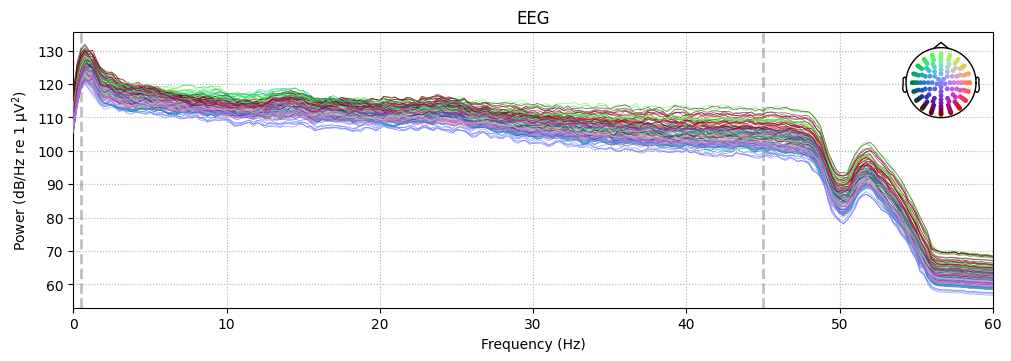

In [35]:
raw_eeg = copy.deepcopy(eeg_data_all_subs["sub01"]["rest_init"])

raw_filtered = apply_mne_butterworth(
                    raw_eeg,
                    apply_notch=False, 
                    filter_type='highpass', 
                    cutoff_freq_high=45, # High-pass cutoff
                    order_high=4,
                )

raw_filtered.plot_psd(fmax=60)

In [34]:
eeg_data_all_subs["sub01"]

{'rest_init': <Raw | rest_ica_cleaned.fif, 128 x 205528 (401.4 s), ~200.9 MiB, data loaded>,
 'reward': <Raw | passive_ica_cleaned.fif, 128 x 205527 (401.4 s), ~200.9 MiB, data loaded>}

In [ ]:
path_analysis_data_new + "eeg_source/"

'D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/eeg_source/'

In [36]:
# ======================================================
# GLOBAL SETTINGS (TEMPLATE-BASED)
# ======================================================
data_dir = path_analysis_data_new + "eeg_source/"
path_trans = data_dir + "biosemi_trans.fif"

bem_path = f'{data_dir}bem-sol.fif'
src_path = f'{data_dir}vol-src.fif.gz'

# ======================================================
# LOAD AAL ATLAS (ONCE)
# ======================================================
aal_nii_path = f'{data_dir}AAL.nii'
aal_img = nib.load(aal_nii_path)

with open(f'{data_dir}AAL_labels.json', 'r') as f:
    aal_labels = json.load(f)

masker = NiftiLabelsMasker(
    labels_img=aal_img,
    standardize=False,
    resampling_target='data'
)
masker_fitted = False   # will fit once on the first stc image, then only transform

# ======================================================
# SOURCE SPACE (load once — it IS used by the forward solution below)
# ======================================================
src = mne.read_source_spaces(src_path)
print(f"Original src in-use vertices: {np.sum(src[0]['inuse'])}")

# ======================================================
# MAIN LOOP
# ======================================================
eeg_source_reconstructed = {}
ep_length = 5

subs = list(eeg_data_all_subs.keys())   # all seven subjects
print("Subjects to process:", subs)

fwd = None   # forward solution and inverse operator are identical for all
inv = None   # subjects/conditions (same montage, template, identity noise cov),
             # so they are computed once, on the first iteration, and reused.

for sub in subs:
    eeg_source_reconstructed[sub] = {}

    for parad in eeg_data_all_subs[sub]:
        print("\n\n\n", "Sub: ", sub, "paradigm: ", parad, "\n\n\n")
        raw = eeg_data_all_subs[sub][parad]

        raw_filtered = apply_mne_butterworth(
                    raw,
                    apply_notch=False,
                    filter_type='highpass',
                    cutoff_freq_high=45,  # NOTE: despite the parameter name, this
                    order_high=4,         # applies a LOW-pass at 45 Hz (verified in logs)
                )

        raw_filtered.set_montage("biosemi128")

        # Explicit common average reference (projection), required for EEG inverse
        if raw_filtered.info['custom_ref_applied']:
            with raw_filtered.info._unlock():
                raw_filtered.info['custom_ref_applied'] = 0
        raw_filtered.set_eeg_reference('average', projection=True)

        raw_epochs = create_epochs_for_source(raw_filtered, epoch_length=ep_length)

        # Identity (ad hoc) noise covariance: full-rank and identical across all
        # subjects and conditions by construction. Replaces the previous
        # compute_covariance(..., tmax=0.) call, which used 1 sample per epoch.
        cov = mne.make_ad_hoc_cov(raw_epochs.info)

        # ----------------------
        # Forward + inverse: computed once, reused everywhere
        # ----------------------
        if fwd is None:
            fwd = mne.make_forward_solution(
                raw_epochs.info,
                trans=path_trans,
                src=src,
                bem=bem_path,
                eeg=True,
                meg=False,
                mindist=0.0,
                n_jobs=1
            )
            inv = make_inverse_operator(raw_epochs.info, fwd, cov)
            src_used = inv["src"]
            print(f"Forward-used src in-use: {np.sum(src_used[0]['inuse'])}")

        snr     = 3.0
        lambda2 = 1.0 / snr ** 2
        method  = "eLORETA"

        # ----------------------
        # Apply inverse
        # ----------------------
        stcs = apply_inverse_epochs(
            raw_epochs,
            inv,
            lambda2=lambda2,
            method=method,
            pick_ori=None,
            return_generator=True
        )

        # ----------------------
        # AAL PARCELLATION
        # ----------------------
        label_ts = []

        for i, stc in enumerate(stcs):
            if i == 0:
                print(f"STC n_sources: {stc.data.shape[0]}")

            stc_img = stc.as_volume(src_used, mri_resolution=False)

            if not masker_fitted:
                masker.fit(stc_img)
                masker_fitted = True

            ts = masker.transform(stc_img)      # (n_times, 116)
            label_ts.append(ts.T)               # (116, n_times)

        label_ts = np.array(label_ts)           # (n_epochs, 116, n_times)
        eeg_source_reconstructed[sub][parad] = label_ts

    Reading a source space...
    [done]
    1 source spaces read
Original src in-use vertices: 24303
Subjects to process: ['sub01', 'sub03', 'sub04', 'sub07', 'sub10', 'sub12', 'sub09']



 Sub:  sub01 paradigm:  rest_init 



Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 151 samples (0.295 s)

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Not setting metadata
80 matching events found
No baseline correction applied
Created an SSP o

C:\Users\specsdcn\AppData\Local\Temp\ipykernel_7124\513830381.py:66: RuntimeWarning: An average reference projection was already added. The data has been left untouched.
  raw_filtered.set_eeg_reference('average', projection=True)


0 bad epochs dropped
Created 83 epochs of 5.0 s each
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 1
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 127 (1 small eigenvalues omitted)
    Computing optimized source covariance (eLORETA)...
        Using independent orientation weights
        Fitting up to 20 iterations (this make take a while)...
        Converged on iteration 10 (6e-07 < 1e-06)
        Updating inverse with weighted eigen leads
[done]
Picked 128 channels from the data
Computing inverse...
    Eigenleads already weighted ... 
Processing epoch : 1 / 83
combining the current components...
STC n_sources: 15110
Processing epoch : 2 / 83
combining the current components...
Processing epoch : 3 / 83
combining the current components...
Processing epoch : 4 / 83
combining the current components...
Processing epoc

C:\Users\specsdcn\AppData\Local\Temp\ipykernel_7124\513830381.py:66: RuntimeWarning: An average reference projection was already added. The data has been left untouched.
  raw_filtered.set_eeg_reference('average', projection=True)


0 bad epochs dropped
Created 82 epochs of 5.0 s each
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 1
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 127 (1 small eigenvalues omitted)
    Computing optimized source covariance (eLORETA)...
        Using independent orientation weights
        Fitting up to 20 iterations (this make take a while)...
        Converged on iteration 10 (6e-07 < 1e-06)
        Updating inverse with weighted eigen leads
[done]
Picked 128 channels from the data
Computing inverse...
    Eigenleads already weighted ... 
Processing epoch : 1 / 82
combining the current components...
STC n_sources: 15110
Processing epoch : 2 / 82
combining the current components...
Processing epoch : 3 / 82
combining the current components...
Processing epoch : 4 / 82
combining the current components...
Processing epoc

...

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 1
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 127 (1 small eigenvalues omitted)
    Computing optimized source covariance (eLORETA)...
        Using independent orientation weights
        Fitting up to 20 iterations (this make take a while)...
        Converged on iteration 10 (6e-07 < 1e-06)
        Updating inverse with weighted eigen leads
[done]
Picked 128 channels from the data
Computing inverse...
    Eigenleads already weighted ... 
Processing epoch : 1 / 44
combining the current components...
STC n_sources: 15110
Processing epoch : 2 / 44
combining the current components...
Processing epoch : 3 / 44
combining the current components...
Processing epoch : 4 / 44
combining the current components...
Processing epoch : 5 / 44
combining the current components...
Proces

C:\Users\specsdcn\AppData\Local\Temp\ipykernel_7124\513830381.py:66: RuntimeWarning: An average reference projection was already added. The data has been left untouched.
  raw_filtered.set_eeg_reference('average', projection=True)


Created 51 epochs of 5.0 s each
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 1
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 127 (1 small eigenvalues omitted)
    Computing optimized source covariance (eLORETA)...
        Using independent orientation weights
        Fitting up to 20 iterations (this make take a while)...
        Converged on iteration 10 (6e-07 < 1e-06)
        Updating inverse with weighted eigen leads
[done]
Picked 128 channels from the data
Computing inverse...
    Eigenleads already weighted ... 
Processing epoch : 1 / 51
combining the current components...
STC n_sources: 15110
Processing epoch : 2 / 51
combining the current components...
Processing epoch : 3 / 51
combining the current components...
Processing epoch : 4 / 51
combining the current components...
Processing epoch : 5 / 51
combining 

C:\Users\specsdcn\AppData\Local\Temp\ipykernel_7124\513830381.py:66: RuntimeWarning: An average reference projection was already added. The data has been left untouched.
  raw_filtered.set_eeg_reference('average', projection=True)


0 bad epochs dropped
Created 67 epochs of 5.0 s each
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 1
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 127 (1 small eigenvalues omitted)
    Computing optimized source covariance (eLORETA)...
        Using independent orientation weights
        Fitting up to 20 iterations (this make take a while)...
        Converged on iteration 10 (6e-07 < 1e-06)
        Updating inverse with weighted eigen leads
[done]
Picked 128 channels from the data
Computing inverse...
    Eigenleads already weighted ... 
Processing epoch : 1 / 67
combining the current components...
STC n_sources: 15110
Processing epoch : 2 / 67
combining the current components...
Processing epoch : 3 / 67
combining the current components...
Processing epoch : 4 / 67
combining the current components...
Processing epoc

In [ ]:
# from mne_connectivity import envelope_correlation

# def bp_gen(label_ts):
#     """Band-pass filter epochs on the fly."""
#     for ts in label_ts:
#         yield mne.filter.filter_data(ts, 512, 8, 13)

# sc_passive_data = eeg_source_reconstructed["sub01"]["rest"]

# corr_obj = envelope_correlation(bp_gen(sc_passive_data), orthogonalize="pairwise")
# corr     = corr_obj.combine()
# corr     = corr.get_data(output="dense")[:, :, 0]

In [ ]:
# data_dir = path_analysis_data_new + "eeg_source/"

# with open(f'{data_dir}AAL_labels.json', 'r') as f:
#     aal_labels = json.load(f)


# fig, ax = plot_fc_matrix(corr, aal_labels, 
#                 plot_type='heatmap',
#                 threshold=None)

Store/Load Source Reconstructed Data

In [ ]:
# with open(path_analysis_data_new + "all_eeg_source_reconstruction_eloreta_45_adhoccov.pkl", "wb") as f:
#     pickle.dump(eeg_source_reconstructed, f)

In [ ]:
# with open(path_analysis_data_new + "all_eeg_source_reconstruction_eloreta_45_adhoccov.pkl", "wb") as f:
#     pickle.dump(eeg_source_reconstructed, f)

#### PSD PLOT

In [27]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ============================================================
# 1. Load the corrected source reconstruction
# ============================================================
with open(path_analysis_data_new + "all_eeg_source_reconstruction_eloreta_45_adhoccov.pkl", "rb") as f:
    eeg_src = pkl.load(f)

print(eeg_src.keys())

sub, parad = "sub09", "rest_init"   # pick the subject/condition with the clearest channel-level alpha
data = eeg_src[sub][parad]          # (n_epochs, 116, n_times)
print("source data shape:", data.shape)

sfreq = 512
nper  = int(5 * sfreq)              # 5-s Welch windows, 50% overlap (matches your pipeline)

# ============================================================
# 2. Source-level PSD (concatenate contiguous epochs per region)
# ============================================================
cont = data.transpose(1, 0, 2).reshape(116, -1)          # (116, total_times)
freqs, psd = welch(cont, fs=sfreq, nperseg=nper, noverlap=nper // 2)
fmask = (freqs >= 0.5) & (freqs <= 45)

# ============================================================
# 3. Sensor-level PSD for the same subject/condition
# ============================================================
raw  = eeg_data_all_subs[sub][parad]
sens = raw.get_data(picks="eeg")                         # (128, n_times)
f_s, psd_s = welch(sens, fs=raw.info["sfreq"], nperseg=nper, noverlap=nper // 2)
smask = (f_s >= 0.5) & (f_s <= 45)

# ============================================================
# 4. Plots
# ============================================================
# AAL indices (0-based, standard order) — verify against your aal_labels once:
# [i for i, l in enumerate(aal_labels) if "Calcarine" in l or "Precuneus" in l]
regions = {42: "Calcarine_L", 43: "Calcarine_R", 44: "Cuneus_L",
           50: "Occipital_Mid_L", 66: "Precuneus_L", 67: "Precuneus_R"}

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) occipital/parietal source regions
for idx, name in regions.items():
    ax[0].semilogy(freqs[fmask], psd[idx, fmask], label=name, lw=1)
ax[0].axvspan(8, 13, alpha=0.15, color="orange")
ax[0].set(xlabel="Frequency (Hz)", ylabel="PSD (a.u.)",
          title="source: occipital/parietal regions")
ax[0].legend(fontsize=7)

# (b) all cerebrum source regions + mean
ax[1].semilogy(freqs[fmask], psd[:90, fmask].T, color="grey", alpha=0.15, lw=0.5)
ax[1].semilogy(freqs[fmask], psd[:90, fmask].mean(axis=0), color="k", lw=2,
               label="mean of 90 regions")
ax[1].axvspan(8, 13, alpha=0.15, color="orange")
ax[1].set(xlabel="Frequency (Hz)", title="source: all cerebrum regions")
ax[1].legend(fontsize=8)

# (c) sensor vs source, shape-normalised (units are incommensurable;
#     each curve divided by its own mean power in 0.5–45 Hz)
src_mean  = psd[:90, fmask].mean(axis=0)
src_norm  = src_mean / src_mean.mean()
sens_mean = psd_s[:, smask].mean(axis=0)
sens_norm = sens_mean / sens_mean.mean()

ax[2].semilogy(f_s[smask], sens_norm, color="tab:blue", lw=2,
               label="sensor (mean of 128 ch)")
ax[2].semilogy(freqs[fmask], src_norm, color="tab:red", lw=2,
               label="source (mean of 90 regions)")
ax[2].axvspan(8, 13, alpha=0.15, color="orange")
ax[2].set(xlabel="Frequency (Hz)", ylabel="normalised PSD (log)",
          title=f"{sub} {parad}: sensor vs source shape")
ax[2].legend(fontsize=8)

plt.suptitle(f"{sub} — {parad}", y=1.02)
plt.tight_layout()
plt.show()

dict_keys(['sub01', 'sub03', 'sub04', 'sub07', 'sub10', 'sub12', 'sub09'])
source data shape: (88, 116, 2560)


In [28]:
# (i) fair comparison: best occipital sensor vs Calcarine_R, shape-normalised
best_sens = psd_s[:, smask][np.argmax(psd_s[:, (f_s>=8)&(f_s<=13)].mean(1))]
reg = psd[43, fmask]   # Calcarine_R
plt.semilogy(f_s[smask], best_sens/best_sens.mean(), label="best alpha sensor")
plt.semilogy(freqs[fmask], reg/reg.mean(), label="Calcarine_R"); plt.axvspan(8,13,alpha=.15,color="orange"); plt.legend()

# (ii) old vs new pickle, same region — the true before/after for the covariance fix